## 0. Kurulum ve İçe Aktarma

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print('Kütüphaneler yüklendi ✓')

Kütüphaneler yüklendi ✓


## 1. Veri Yükleme ve Kalite Kontrolü

CSV dosyasını Google Drive'a yükleyip path'i aşağıya gir.

In [3]:
# ⚠️ CSV dosyasının Drive'daki tam yolunu gir
CSV_PATH = 'C:\\Users\\BUSRA\\Documents\\GitHub\\IoBDataAnalysis\\Veriler\\oturum_hava_birlesik.csv'  # <-- buraya kendi path'ini yaz

df = pd.read_csv(CSV_PATH)

print('=== SHAPE ===')
print(f'{df.shape[0]:,} satır, {df.shape[1]} kolon')

print('\n=== NULL DEĞERLER ===')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'Null değer yok ✓')

print('\n=== HEDEF DEĞİŞKEN: oturum_sure_dk ===')
print(df['oturum_sure_dk'].describe())

print('\n=== OUTLIER_FLAG ===')
print(df['outlier_flag'].value_counts(dropna=False))

print('\n=== MASA GRUBU ===')
print(df['masa_grup'].value_counts())

print('\n=== YIL DAĞILIMI ===')
print(df['yil'].value_counts().sort_index())

=== SHAPE ===
388,411 satır, 34 kolon

=== NULL DEĞERLER ===
outlier_flag    353605
dtype: int64

=== HEDEF DEĞİŞKEN: oturum_sure_dk ===
count    388411.000000
mean         51.754948
std          88.270571
min           0.000000
25%          15.000000
50%          27.000000
75%          42.000000
max        1439.000000
Name: oturum_sure_dk, dtype: float64

=== OUTLIER_FLAG ===
outlier_flag
NaN             353605
uzun_oturum      22222
sifir_sureli     12584
Name: count, dtype: int64

=== MASA GRUBU ===
masa_grup
İç Salon    171880
Paket       122015
Bahçe        94516
Name: count, dtype: int64

=== YIL DAĞILIMI ===
yil
2012     7806
2013    22517
2014    28397
2015    33049
2016    34293
2017    32751
2018    33105
2019    34888
2020    28358
2021    34613
2022    32804
2023    30255
2024    27585
2025     7990
Name: count, dtype: int64


## 2. Feature Engineering

In [4]:
# Dönem türet (eğer 'donem' kolonu yoksa)
if 'donem' not in df.columns:
    def get_donem(yil):
        if yil < 2020: return 'Pre-COVID'
        elif yil <= 2022: return 'COVID'
        else: return 'Post-COVID'
    df['donem'] = df['yil'].apply(get_donem)
    print('donem kolonu türetildi ✓')
else:
    print('donem kolonu zaten mevcut ✓')

# Hafta sonu flag
df['hafta_sonu'] = df['gun_adi'].isin(['Cumartesi', 'Pazar']).astype(int)

# Hissedilen sıcaklık farkı
df['sicaklik_hissedilen_fark'] = df['temperature_2m'] - df['apparent_temperature']

# Yağış binary
df['yagis_var'] = (df['precipitation'] > 0).astype(int)

# Kar binary
df['kar_var'] = (df['snowfall'] > 0).astype(int)

# Oturum dilimi
def oturum_dilimi(saat):
    if saat < 10: return 'sabah'
    elif saat < 13: return 'ogle'
    elif saat < 17: return 'ikindi'
    else: return 'aksam'

df['oturum_dilimi'] = df['saat'].apply(oturum_dilimi)

print('Feature engineering tamamlandı ✓')
print(f'Yeni kolonlar: donem, hafta_sonu, sicaklik_hissedilen_fark, yagis_var, kar_var, oturum_dilimi')

donem kolonu türetildi ✓
Feature engineering tamamlandı ✓
Yeni kolonlar: donem, hafta_sonu, sicaklik_hissedilen_fark, yagis_var, kar_var, oturum_dilimi


In [5]:
# One-hot encoding ve feature listesi hazırla
cat_cols = ['masa_grup', 'gun_adi', 'donem', 'yagis_kategori', 'sicaklik_aralik', 'oturum_dilimi']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

hava_features = [
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'dewpoint_2m', 'precipitation', 'rain', 'snowfall', 'windspeed_10m',
    'cloudcover', 'pressure_msl', 'shortwave_radiation', 'is_day',
    'yagis_var', 'kar_var', 'sicaklik_hissedilen_fark'
]
zaman_features = ['saat', 'ay', 'hafta_no', 'hafta_sonu']
ohe_cols = [c for c in df_encoded.columns if any(c.startswith(cat + '_') for cat in cat_cols)]
all_features = hava_features + zaman_features + ohe_cols
target = 'oturum_sure_dk'

# İki veri seti
df_full = df_encoded[all_features + [target]].dropna()
normal_mask = df['outlier_flag'].isna()
df_clean = df_encoded[normal_mask][all_features + [target]].dropna()

print(f'Full dataset  (outlier dahil): {len(df_full):,} satır')
print(f'Clean dataset (outlier siz):   {len(df_clean):,} satır')
print(f'Toplam feature sayısı: {len(all_features)}')

Full dataset  (outlier dahil): 388,411 satır
Clean dataset (outlier siz):   353,605 satır
Toplam feature sayısı: 47


## 3. Cohen's d — Etki Büyüklükleri

Kruskal-Wallis anlamlı çıktı, ama pratik önemi ne? Cohen's d bunu ölçer.
- d < 0.2 → çok küçük
- 0.2 ≤ d < 0.5 → küçük
- 0.5 ≤ d < 0.8 → orta
- d ≥ 0.8 → büyük

In [6]:
def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_std = np.sqrt(((n1-1)*g1.std()**2 + (n2-1)*g2.std()**2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_std

def interpret_d(d):
    d = abs(d)
    if d < 0.2: return 'çok küçük'
    elif d < 0.5: return 'küçük'
    elif d < 0.8: return 'orta'
    else: return 'büyük'

df_normal = df[normal_mask].copy()

# --- Dönem karşılaştırması ---
pre   = df_normal[df_normal['donem'] == 'Pre-COVID']['oturum_sure_dk']
covid = df_normal[df_normal['donem'] == 'COVID']['oturum_sure_dk']
post  = df_normal[df_normal['donem'] == 'Post-COVID']['oturum_sure_dk']

print('=== DÖNEM ETKİ BÜYÜKLÜKLERİ ===')
for label, g1, g2 in [
    ('Pre-COVID vs COVID', pre, covid),
    ('Pre-COVID vs Post-COVID', pre, post),
    ('COVID vs Post-COVID', covid, post)
]:
    d = cohens_d(g1, g2)
    print(f'  {label:30s} d={d:+.3f}  ({interpret_d(d)})')

print(f'\n  Pre-COVID  ort: {pre.mean():.1f} dk  (n={len(pre):,})')
print(f'  COVID      ort: {covid.mean():.1f} dk  (n={len(covid):,})')
print(f'  Post-COVID ort: {post.mean():.1f} dk  (n={len(post):,})')

# --- Yağış etkisi ---
kuru     = df_normal[df_normal['precipitation'] == 0]['oturum_sure_dk']
yagisli  = df_normal[df_normal['precipitation'] > 0]['oturum_sure_dk']
d_yagis  = cohens_d(kuru, yagisli)

print('\n=== YAĞIŞ ETKİ BÜYÜKLÜKLERİ ===')
print(f'  Kuru vs Yağışlı: d={d_yagis:+.3f}  ({interpret_d(d_yagis)})')
print(f'  Kuru ort: {kuru.mean():.1f} dk  (n={len(kuru):,})')
print(f'  Yağışlı ort: {yagisli.mean():.1f} dk  (n={len(yagisli):,})')

# --- Masa grubu etkisi ---
ic    = df_normal[df_normal['masa_grup'] == 'İç Salon']['oturum_sure_dk']
bahce = df_normal[df_normal['masa_grup'] == 'Bahçe']['oturum_sure_dk']
paket = df_normal[df_normal['masa_grup'] == 'Paket']['oturum_sure_dk']

print('\n=== MASA GRUBU ETKİ BÜYÜKLÜKLERİ ===')
for label, g1, g2 in [
    ('İç Salon vs Bahçe', ic, bahce),
    ('İç Salon vs Paket', ic, paket),
    ('Bahçe vs Paket', bahce, paket)
]:
    d = cohens_d(g1, g2)
    print(f'  {label:25s} d={d:+.3f}  ({interpret_d(d)})')

print(f'\n  İç Salon ort: {ic.mean():.1f} dk  (n={len(ic):,})')
print(f'  Bahçe    ort: {bahce.mean():.1f} dk  (n={len(bahce):,})')
print(f'  Paket    ort: {paket.mean():.1f} dk  (n={len(paket):,})')

=== DÖNEM ETKİ BÜYÜKLÜKLERİ ===
  Pre-COVID vs COVID             d=-0.100  (çok küçük)
  Pre-COVID vs Post-COVID        d=+0.145  (çok küçük)
  COVID vs Post-COVID            d=+0.215  (küçük)

  Pre-COVID  ort: 33.3 dk  (n=208,616)
  COVID      ort: 36.7 dk  (n=81,360)
  Post-COVID ort: 29.2 dk  (n=63,629)

=== YAĞIŞ ETKİ BÜYÜKLÜKLERİ ===
  Kuru vs Yağışlı: d=-0.016  (çok küçük)
  Kuru ort: 33.2 dk  (n=298,080)
  Yağışlı ort: 33.7 dk  (n=55,525)

=== MASA GRUBU ETKİ BÜYÜKLÜKLERİ ===
  İç Salon vs Bahçe         d=-0.209  (küçük)
  İç Salon vs Paket         d=-0.518  (orta)
  Bahçe vs Paket            d=-0.357  (küçük)

  İç Salon ort: 27.7 dk  (n=169,012)
  Bahçe    ort: 31.4 dk  (n=93,597)
  Paket    ort: 45.7 dk  (n=90,996)


## 4. Gelir Kaybı Analizi (Yağışlı Günlerde Bahçe)

In [7]:
df_bahce       = df_normal[df_normal['masa_grup'] == 'Bahçe']
bahce_kuru     = df_bahce[df_bahce['precipitation'] == 0]
bahce_yagisli  = df_bahce[df_bahce['precipitation'] > 0]

ort_tutar  = df_normal['toplam_tutar'].mean()
ort_miktar = df_normal['toplam_miktar'].mean()

# Kuru günlerde Bahçe'nin toplam oturum içindeki oranı
toplam_kuru    = len(df_normal[df_normal['precipitation'] == 0])
toplam_yagisli = len(df_normal[df_normal['precipitation'] > 0])

normal_bahce_orani    = len(bahce_kuru) / toplam_kuru
beklenen_bahce_yagis  = toplam_yagisli * normal_bahce_orani
gercek_bahce_yagis    = len(bahce_yagisli)
kayip_oturum          = beklenen_bahce_yagis - gercek_bahce_yagis

print('=== GELİR KAYBI ANALİZİ ===')
print(f'Ortalama sipariş tutarı:          {ort_tutar:.1f} TL')
print(f'Ortalama sipariş miktarı:         {ort_miktar:.1f} ürün')
print()
print(f'Kuru havada Bahçe oturumu:        {len(bahce_kuru):,}')
print(f'Yağışlı havada Bahçe oturumu:     {gercek_bahce_yagis:,}')
print(f'Beklenen Bahçe oturumu (yağışlı): {beklenen_bahce_yagis:.0f}')
print(f'Tahmini kayıp oturum:             {kayip_oturum:.0f}')
print()
print(f'Tahmini gelir kaybı:              {kayip_oturum * ort_tutar:,.0f} TL')
print(f'(Yağışlı gün başına kayıp):       {kayip_oturum * ort_tutar / max(toplam_yagisli/24, 1):,.0f} TL/gün  [yaklaşık]')

=== GELİR KAYBI ANALİZİ ===
Ortalama sipariş tutarı:          176.2 TL
Ortalama sipariş miktarı:         6.1 ürün

Kuru havada Bahçe oturumu:        83,112
Yağışlı havada Bahçe oturumu:     10,485
Beklenen Bahçe oturumu (yağışlı): 15482
Tahmini kayıp oturum:             4997

Tahmini gelir kaybı:              880,619 TL
(Yağışlı gün başına kayıp):       381 TL/gün  [yaklaşık]


## 5. Model Eğitimi

İki ayrı model kuruyoruz:
- **Model 1**: Tüm veri (outlier dahil) — genel tablo
- **Model 2**: Temiz veri (outlier'sız) — operasyonel model

In [8]:
def train_evaluate(df_model, dataset_name, all_features, target):
    X = df_model[all_features]
    y = df_model[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models = {
        'Linear Regression':  LinearRegression(),
        'Ridge Regression':   Ridge(alpha=1.0),
        'Random Forest':      RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, random_state=42)
    }

    print(f'\n=== {dataset_name} ({len(df_model):,} satır) ===')
    print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
    print('-' * 55)

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)

        print(f'{name:<25} {rmse:>8.2f} {mae:>8.2f} {r2:>8.4f}')
        results[name] = {'model': model, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
                         'y_test': y_test, 'y_pred': y_pred}

    return results

results_full  = train_evaluate(df_full,  'MODEL 1 — Tüm Veri (Outlier Dahil)', all_features, target)
results_clean = train_evaluate(df_clean, 'MODEL 2 — Temiz Veri (Outlier Siz)',  all_features, target)


=== MODEL 1 — Tüm Veri (Outlier Dahil) (388,411 satır) ===
Model                         RMSE      MAE       R²
-------------------------------------------------------
Linear Regression            78.74    46.58   0.2012
Ridge Regression             78.74    46.58   0.2012
Random Forest                67.01    31.76   0.4213
Gradient Boosting            70.55    36.87   0.3587

=== MODEL 2 — Temiz Veri (Outlier Siz) (353,605 satır) ===
Model                         RMSE      MAE       R²
-------------------------------------------------------
Linear Regression            31.04    19.01   0.0753
Ridge Regression             31.04    19.01   0.0753
Random Forest                29.26    17.84   0.1780
Gradient Boosting            29.53    18.16   0.1628


## 6. Feature Importance

=== TOP 20 FEATURE IMPORTANCE (Random Forest - Temiz Veri) ===
saat                        0.100256
pressure_msl                0.089842
shortwave_radiation         0.084463
windspeed_10m               0.078885
dewpoint_2m                 0.064660
relative_humidity_2m        0.063127
masa_grup_Paket             0.062945
cloudcover                  0.057239
temperature_2m              0.056804
sicaklik_hissedilen_fark    0.055849
hafta_no                    0.054857
apparent_temperature        0.053222
donem_Post-COVID            0.021499
oturum_dilimi_ogle          0.016087
ay                          0.013906
donem_COVID                 0.010460
oturum_dilimi_aksam         0.010068
donem_Pre-COVID             0.009421
gun_adi_Saturday            0.008831
oturum_dilimi_ikindi        0.008117


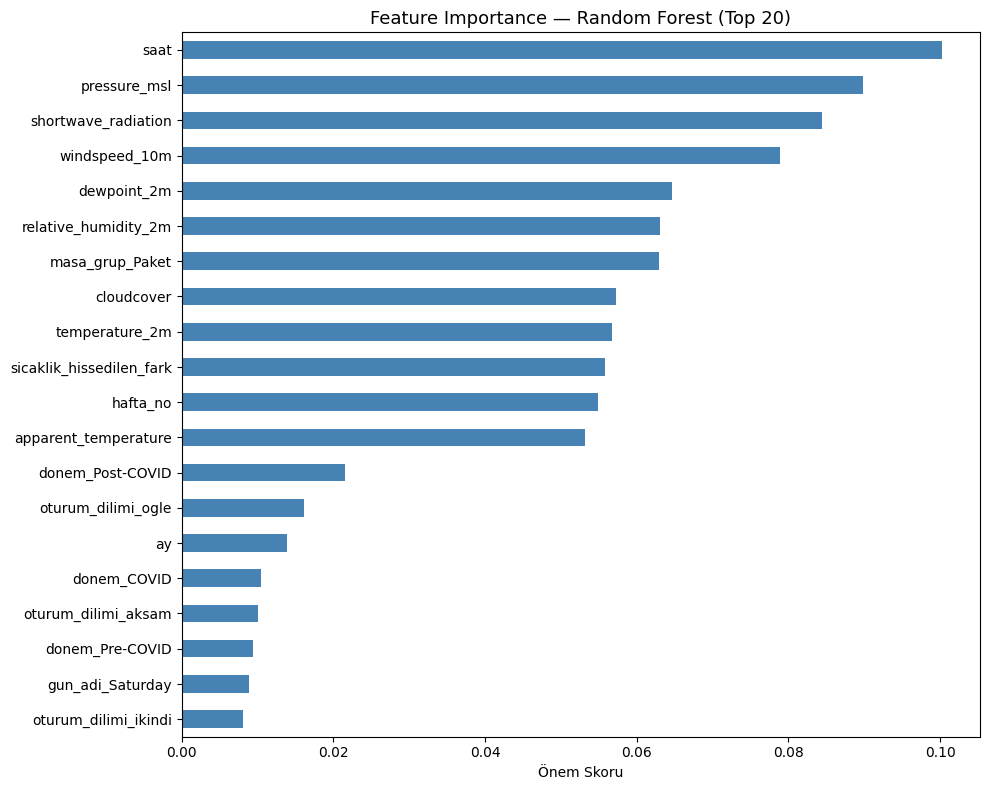

Grafik kaydedildi: feature_importance.png


In [9]:
# Random Forest — Temiz veri
rf_model = results_clean['Random Forest']['model']

importances = pd.Series(
    rf_model.feature_importances_,
    index=all_features
).sort_values(ascending=False)

print('=== TOP 20 FEATURE IMPORTANCE (Random Forest - Temiz Veri) ===')
print(importances.head(20).to_string())

# Görsel
fig, ax = plt.subplots(figsize=(10, 8))
importances.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Random Forest (Top 20)', fontsize=13)
ax.set_xlabel('Önem Skoru')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Grafik kaydedildi: feature_importance.png')

## 7. Cross-Validation (5-Fold)

In [10]:
X_clean = df_clean[all_features]
y_clean = df_clean[target]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42)
}

print('=== 5-FOLD CROSS VALIDATION (Temiz Veri) ===')
print(f'{"Model":<25} {"R² (ort ± std)":>20} {"RMSE (ort ± std)":>20}')
print('-' * 70)

for name, model in cv_models.items():
    cv_r2   = cross_val_score(model, X_clean, y_clean, cv=kf, scoring='r2')
    cv_rmse = np.sqrt(-cross_val_score(model, X_clean, y_clean, cv=kf,
                                        scoring='neg_mean_squared_error'))
    r2_str   = f'{cv_r2.mean():.4f} ± {cv_r2.std():.4f}'
    rmse_str = f'{cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}'
    print(f'{name:<25} {r2_str:>20} {rmse_str:>20}')

=== 5-FOLD CROSS VALIDATION (Temiz Veri) ===
Model                           R² (ort ± std)     RMSE (ort ± std)
----------------------------------------------------------------------
Linear Regression              0.0734 ± 0.0029         30.89 ± 0.22
Random Forest                  0.1670 ± 0.0089         29.28 ± 0.13
Gradient Boosting              0.1593 ± 0.0037         29.42 ± 0.19


NOT: Şu an modelin tahmin etmeye çalıştığı şey şu: "Bu oturumda müşteri kaç dakika oturdu?" — ve bunu sadece hava + zaman + masa grubu bilgisiyle tahmin etmeye çalışıyoruz. Aslında oturum süresini en çok etkileyen şeyler muhtemelen kaçtaki insan sayısı, masada kaç kişi var, siparişin ne zaman geldi, özel bir gün mü — bunların hiçbiri modelde yok. Yani R²=0.178 aslında "elimizdeki değişkenlerle açıklanabilecek maksimuma yakın olabilir" diyebiliriz, ama bunu kanıtlamamız lazım.

## 8. Sonuç Özeti — Makale İçin Çıktılar

In [11]:
print('=== SONUÇ ÖZETİ ===')
print()

# En iyi model
best_model_name = max(results_clean, key=lambda k: results_clean[k]['R2'])
best = results_clean[best_model_name]
print(f'En iyi model: {best_model_name}')
print(f'  RMSE: {best["RMSE"]:.2f} dk')
print(f'  MAE:  {best["MAE"]:.2f} dk')
print(f'  R²:   {best["R2"]:.4f}')

# Outlier etkisi
r2_full  = results_full[best_model_name]['R2']
r2_clean = results_clean[best_model_name]['R2']
print()
print(f'Outlier etkisi ({best_model_name}):')
print(f'  Outlier dahil R²: {r2_full:.4f}')
print(f'  Outlier siz R²:   {r2_clean:.4f}')
print(f'  Fark:             {r2_clean - r2_full:+.4f}')

# En önemli hava değişkeni
hava_only = importances[importances.index.isin(hava_features)]
print()
print('En önemli hava değişkenleri (Top 5):')
for feat, imp in hava_only.head(5).items():
    print(f'  {feat:<35} {imp:.4f}')

print()

=== SONUÇ ÖZETİ ===

En iyi model: Random Forest
  RMSE: 29.26 dk
  MAE:  17.84 dk
  R²:   0.1780

Outlier etkisi (Random Forest):
  Outlier dahil R²: 0.4213
  Outlier siz R²:   0.1780
  Fark:             -0.2433

En önemli hava değişkenleri (Top 5):
  pressure_msl                        0.0898
  shortwave_radiation                 0.0845
  windspeed_10m                       0.0789
  dewpoint_2m                         0.0647
  relative_humidity_2m                0.0631

